In [1]:
!pip install -q transformers datasets trl peft bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.0 MB/s eta 0:00:00


 PHASE 1: DATA PREPROCESSING & EDA
1/3 DOWNLOADING & LOADING DATASETS


README.md: 0.00B [00:00, ?B/s]

harmless-base/train.jsonl.gz:   0%|          | 0.00/13.2M [00:00<?, ?B/s]

helpful-base/train.jsonl.gz:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

helpful-online/train.jsonl.gz:   0%|          | 0.00/20.1M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  Tokenizer Model: gpt2
  Vocabulary Size: 50,257 tokens
  Max Model Context Length: 1024 tokens
 Sample 0 Token Count: 119 tokens
GENERATING TOKEN LENGTH VISUALIZATION


Token indices sequence length is longer than the specified maximum sequence length for this model (1251 > 1024). Running this sequence through the model will result in indexing errors


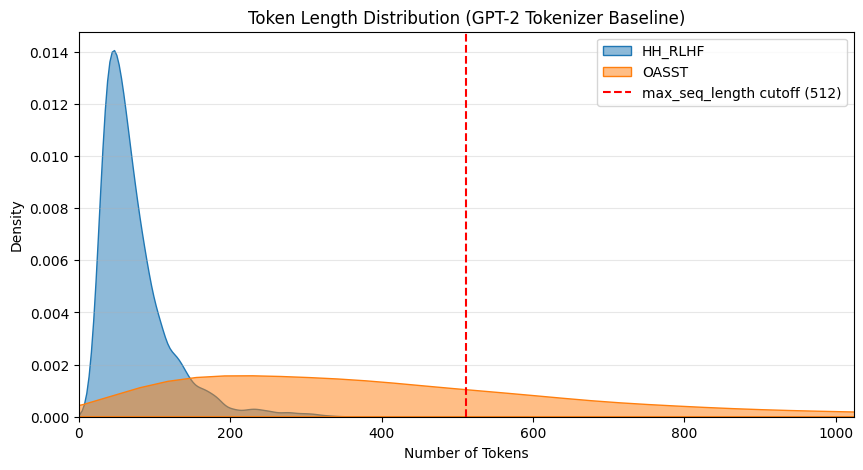

Phase 1 Complete. Data is verified and ready for SFT.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer
print("="*60)
print(" PHASE 1: DATA PREPROCESSING & EDA")
print("="*60)

# Parse HH-RLHF multi-turn dialogue into prompt + chosen response
def parse_anthropic_text(text):
    text_parts = text.split("\n\nAssistant:")
    user_prompt = text_parts[0] + "\n\nAssistant:"
    assistant_reply = text_parts[1] if len(text_parts) > 1 else ""
    return user_prompt.strip(), assistant_reply.strip()
print("1/3 DOWNLOADING & LOADING DATASETS")
data_hh = load_dataset("Anthropic/hh-rlhf", split="train[:12000]")
data_oasst = load_dataset("tasksource/oasst1_pairwise_rlhf_reward", split="train[:10000]")
print(f"   HH-RLHF loaded: {len(data_hh):,} rows.")
print(f"   Original Columns: {data_hh.column_names}")
print(f"   OpenAssistant loaded: {len(data_oasst):,} rows.")
print(f"   Original Columns: {data_oasst.column_names}")
print("\n 2/3 PREPROCESSING & FORMATTING")
# Format HH-RLHF rows into a single text string for SFT

def prepare_hh_data(row):
    user_prompt, selected_text = parse_anthropic_text(row['chosen'])
    return {"text": f"{user_prompt} {selected_text}"}
def prepare_oasst_data(row):
    return {"text": f"{row['prompt']} {row['chosen']}"}
hh_processed = data_hh.map(prepare_hh_data, remove_columns=data_hh.column_names)
oasst_processed = data_oasst.map(prepare_oasst_data, remove_columns=data_oasst.column_names)
print(f"  HH-RLHF formatted. New Columns: {hh_processed.column_names}")
print(f"  OpenAssistant formatted. New Columns: {oasst_processed.column_names}")
print("\n DATA INSPECTION (Sample 0 from OpenAssistant):")
print("-" * 50)
print(oasst_processed[0]['text'][:350] + "[TRUNCATED FOR DISPLAY]")
print("-" * 50)

# 90/10 train-val split with fixed seed for reproducibility across all experiments
hh_train_val = hh_processed.train_test_split(test_size=0.1, seed=42)
oasst_train_val = oasst_processed.train_test_split(test_size=0.1, seed=42)
corpus_dict = {
    "hh_rlhf": hh_train_val,
    "oasst": oasst_train_val
}
print("\n Train/Val Splits created (90/10).")
print(f"     HH-RLHF   | Train: {len(hh_train_val['train']):,} | Val: {len(hh_train_val['test']):,}")
print(f"     OASST     | Train: {len(oasst_train_val['train']):,} | Val: {len(oasst_train_val['test']):,}")
print("\n3/3 LOADING TOKENIZER FOR EDA")
base_model_id = "gpt2"
eval_tokenizer = AutoTokenizer.from_pretrained(base_model_id)
print(f"  Tokenizer Model: {base_model_id}")
print(f"  Vocabulary Size: {eval_tokenizer.vocab_size:,} tokens")
print(f"  Max Model Context Length: {eval_tokenizer.model_max_length} tokens")
example_string = oasst_train_val['train'][0]['text']
example_encoded = eval_tokenizer(example_string)
print(f" Sample 0 Token Count: {len(example_encoded['input_ids'])} tokens")
print("GENERATING TOKEN LENGTH VISUALIZATION")

# Plot token length distributions to understand truncation impact before training.
# The red line at 512 shows how much of OASST will be cut during SFT.
def visualize_token_distribution(corpus_dict, tok_obj):
    plt.figure(figsize=(10, 5))
    for dataset_key, split_data in corpus_dict.items():
        token_counts = [len(tok_obj(text)["input_ids"]) for text in split_data["train"]["text"]]
        sns.kdeplot(token_counts, fill=True, label=dataset_key.upper(), alpha=0.5)
    plt.title("Token Length Distribution (GPT-2 Tokenizer Baseline)")
    plt.xlabel("Number of Tokens")
    plt.ylabel("Density")
    plt.xlim(0, 1024)
    plt.axvline(x=512, color='red', linestyle='--', label="max_seq_length cutoff (512)")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
visualize_token_distribution(corpus_dict, eval_tokenizer)
print("Phase 1 Complete. Data is verified and ready for SFT.")

In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import warnings
warnings.filterwarnings("ignore")

import torch
import gc
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

print("\n1/4 LOADING DATASETS")
data_hh = load_dataset("Anthropic/hh-rlhf", split="train[:12000]")
data_oasst = load_dataset("tasksource/oasst1_pairwise_rlhf_reward", split="train[:10000]")

def parse_anthropic_text(text):
    text_parts = text.split("\n\nAssistant:")
    user_prompt = text_parts[0] + "\n\nAssistant:"
    assistant_reply = text_parts[1] if len(text_parts) > 1 else ""
    return user_prompt.strip(), assistant_reply.strip()

def prepare_hh_data(row):
    user_prompt, selected_text = parse_anthropic_text(row['chosen'])
    return {"text": f"{user_prompt} {selected_text}"}

def prepare_oasst_data(row):
    return {"text": f"{row['prompt']} {row['chosen']}"}

hh_processed = data_hh.map(prepare_hh_data, remove_columns=data_hh.column_names)
oasst_processed = data_oasst.map(prepare_oasst_data, remove_columns=data_oasst.column_names)

corpus_dict = {
    "hh_rlhf": hh_processed.train_test_split(test_size=0.1, seed=42),
    "oasst":   oasst_processed.train_test_split(test_size=0.1, seed=42),
}

print(f"  HH-RLHF  | Train: {len(corpus_dict['hh_rlhf']['train']):,} | Val: {len(corpus_dict['hh_rlhf']['test']):,}")
print(f"   OASST    | Train: {len(corpus_dict['oasst']['train']):,} | Val: {len(corpus_dict['oasst']['test']):,}")

print("\n2/4 BUILDING TRAINING CONFIG")

base_train_args = SFTConfig(
    output_dir="./models/baseline_sft",
    dataset_text_field="text",
    max_length=512,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    save_strategy="epoch",
    eval_strategy="epoch",
    logging_steps=20,
    num_train_epochs=1,
    optim="paged_adamw_32bit",
    fp16=False,
    bf16=False,
    report_to="none",
)

def execute_sft(model_obj, tok_obj, dataset_key, split_data, model_alias):
    print(f"\n{'-'*50}")
    print(f" STARTING SFT: {model_alias.upper()} on {dataset_key.upper()}")
    print(f"{'-'*50}")
    run_out_path = f"./models/baseline_sft/{model_alias}_{dataset_key}"
    base_train_args.output_dir = run_out_path
    trainer_instance = SFTTrainer(
        model=model_obj,
        train_dataset=split_data["train"],
        eval_dataset=split_data["test"],
        processing_class=tok_obj,
        args=base_train_args,
    )
    trainer_instance.train()
    trainer_instance.model.save_pretrained(run_out_path)
    tok_obj.save_pretrained(run_out_path)
    print(f" Saved to {run_out_path}")

print("\n3/4 TRAINING GPT-2")

# GPT-2 uses Conv1D layers (transposed weights) so fan_in_fan_out=True is required.
# Without this flag, LoRA applies the wrong weight orientation and training silently fails.
lora_setup_gpt2 = LoraConfig(
    r=16,
    lora_alpha=32,
    task_type="CAUSAL_LM",
    fan_in_fan_out=True,
)

tok_gpt2 = AutoTokenizer.from_pretrained("gpt2")
tok_gpt2.pad_token = tok_gpt2.eos_token

model_gpt2 = AutoModelForCausalLM.from_pretrained("gpt2")
model_gpt2 = get_peft_model(model_gpt2, lora_setup_gpt2)

print(f"  GPT-2 trainable params: ", end="")
model_gpt2.print_trainable_parameters()

for dataset_key, split_data in corpus_dict.items():
    execute_sft(model_gpt2, tok_gpt2, dataset_key, split_data, "gpt2")

del model_gpt2, tok_gpt2
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()
print(" GPT-2 released from memory.")

print("\n4/4 TRAINING TINYLLAMA")

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

lora_setup_llama = LoraConfig(
    r=16,
    lora_alpha=32,
    task_type="CAUSAL_LM",
)

tok_llama = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")
tok_llama.pad_token = tok_llama.eos_token

model_llama = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.float16,
)
model_llama = get_peft_model(model_llama, lora_setup_llama)


# T4 fix TinyLlama non-quantised layers default to bfloat16 but AMP expects float16.
# Manually casting LoRA adapter params prevents a NotImplementedError at the first optimizer step.
for name, param in model_llama.named_parameters():
    if param.requires_grad:
        param.data = param.data.to(torch.float16)

print(f"  TinyLlama trainable params: ", end="")
model_llama.print_trainable_parameters()

for dataset_key, split_data in corpus_dict.items():
    execute_sft(model_llama, tok_llama, dataset_key, split_data, "tinyllama")

del model_llama, tok_llama
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()

print(" TinyLlama released from memory.")
print("\nPhase 2 complete — all 4 models trained and saved.")

Using device: cuda

1/4 LOADING DATASETS
  HH-RLHF  | Train: 10,800 | Val: 1,200
   OASST    | Train: 9,000 | Val: 1,000

2/4 BUILDING TRAINING CONFIG

3/4 TRAINING GPT-2


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

  GPT-2 trainable params: trainable params: 589,824 || all params: 125,029,632 || trainable%: 0.4717

--------------------------------------------------
 STARTING SFT: GPT2 on HH_RLHF
--------------------------------------------------


...

Adding EOS to eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,1.607637,1.648882


 Saved to ./models/baseline_sft/tinyllama_oasst
 TinyLlama released from memory.

Phase 2 complete — all 4 models trained and saved.


In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import gc
from datasets import load_dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, TaskType
from trl import RewardTrainer, RewardConfig

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# TinyLlama's backbone emits bfloat16 hidden states but the score projection expects float16.
# This wrapper casts inputs to the score layer's dtype at runtime to prevent a crash.
class DtypeSafeScoreHead(nn.Module):
    def __init__(self, original_score: nn.Linear):
        super().__init__()
        self.score = original_score

    def forward(self, x):
        return self.score(x.to(self.score.weight.dtype))

def wrap_score_head(model):
    score_wrapper = model.base_model.model.score
    active = score_wrapper.active_adapters[0]
    original_linear = score_wrapper.modules_to_save[active]
    score_wrapper.modules_to_save[active] = DtypeSafeScoreHead(original_linear)
    print("  Score head wrapped with DtypeSafeScoreHead")
    return model

print("\n1/4 LOADING & FORMATTING PREFERENCE DATA")
data_hh = load_dataset("Anthropic/hh-rlhf", split="train[:12000]")
data_oasst = load_dataset("tasksource/oasst1_pairwise_rlhf_reward", split="train[:10000]")

def parse_anthropic_text(text):
    text_parts = text.split("\n\nAssistant:")
    user_prompt = text_parts[0] + "\n\nAssistant:"
    assistant_reply = text_parts[1] if len(text_parts) > 1 else ""
    return user_prompt.strip(), assistant_reply.strip()

def prepare_hh_data(row):
    user_prompt, selected_text = parse_anthropic_text(row['chosen'])
    _, rejected_text = parse_anthropic_text(row['rejected'])
    return {
        "chosen": f"{user_prompt} {selected_text}",
        "rejected": f"{user_prompt} {rejected_text}",
    }

def prepare_oasst_data(row):
    return {
        "chosen": f"{row['prompt']} {row['chosen']}",
        "rejected": f"{row['prompt']} {row['rejected']}",
    }

hh_processed = data_hh.map(prepare_hh_data, remove_columns=data_hh.column_names)
oasst_processed = data_oasst.map(prepare_oasst_data, remove_columns=data_oasst.column_names)

corpus_dict = {
    "hh_rlhf": hh_processed.train_test_split(test_size=0.1, seed=42),
    "oasst":   oasst_processed.train_test_split(test_size=0.1, seed=42),
}

print(f"  HH-RLHF  | Train: {len(corpus_dict['hh_rlhf']['train']):,} | Val: {len(corpus_dict['hh_rlhf']['test']):,}")
print(f"   OASST    | Train: {len(corpus_dict['oasst']['train']):,} | Val: {len(corpus_dict['oasst']['test']):,}")

print("\n2/4 BUILDING REWARD CONFIG")

# Lower learning rate than SFT (2e-5 vs 2e-4) reward model needs finer updates
# to learn preference ordering without overshooting the Bradley-Terry loss minimum.
base_train_args = RewardConfig(
    output_dir="./models/reward_models",
    max_length=512,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    lr_scheduler_type="cosine",
    save_strategy="epoch",
    eval_strategy="epoch",
    logging_steps=20,
    num_train_epochs=1,
    optim="paged_adamw_32bit",
    fp16=False,
    bf16=False,
    report_to="none",
)

def execute_rm(model_obj, tok_obj, dataset_key, split_data, model_alias):
    print(f"\n{'-'*50}")
    print(f" STARTING RM: {model_alias.upper()} on {dataset_key.upper()}")
    print(f"{'-'*50}")

    run_out_path = f"./models/reward_models/{model_alias}_{dataset_key}"
    base_train_args.output_dir = run_out_path

    trainer_instance = RewardTrainer(
        model=model_obj,
        processing_class=tok_obj,
        args=base_train_args,
        train_dataset=split_data["train"],
        eval_dataset=split_data["test"],
    )

    trainer_instance.train()
    trainer_instance.model.save_pretrained(run_out_path)
    tok_obj.save_pretrained(run_out_path)
    print(f" Saved RM to {run_out_path}")

print("\n3/4 TRAINING GPT-2 REWARD MODEL")

lora_setup_gpt2 = LoraConfig(
    r=16,
    lora_alpha=32,
    task_type=TaskType.SEQ_CLS,
    fan_in_fan_out=True,
)

tok_gpt2 = AutoTokenizer.from_pretrained("gpt2")
tok_gpt2.pad_token = tok_gpt2.eos_token

model_gpt2 = AutoModelForSequenceClassification.from_pretrained("gpt2", num_labels=1)
model_gpt2.config.pad_token_id = tok_gpt2.pad_token_id
model_gpt2 = get_peft_model(model_gpt2, lora_setup_gpt2)

print(f"  GPT-2 trainable params: ", end="")
model_gpt2.print_trainable_parameters()

for dataset_key, split_data in corpus_dict.items():
    execute_rm(model_gpt2, tok_gpt2, dataset_key, split_data, "gpt2")

del model_gpt2, tok_gpt2
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()
print(" GPT-2 released from memory.")

print("\n4/4 TRAINING TINYLLAMA REWARD MODEL")

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

lora_setup_llama = LoraConfig(
    r=16,
    lora_alpha=32,
    task_type=TaskType.SEQ_CLS,
)

tok_llama = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")
tok_llama.pad_token = tok_llama.eos_token

model_llama = AutoModelForSequenceClassification.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    num_labels=1,
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.float16,
)
model_llama.config.pad_token_id = tok_llama.pad_token_id
model_llama = get_peft_model(model_llama, lora_setup_llama)

for name, param in model_llama.named_parameters():
    if param.requires_grad and "score" not in name:
        param.data = param.data.to(torch.float16)

model_llama = wrap_score_head(model_llama)

print(f"  TinyLlama trainable params: ", end="")
model_llama.print_trainable_parameters()

for dataset_key, split_data in corpus_dict.items():
    execute_rm(model_llama, tok_llama, dataset_key, split_data, "tinyllama")

del model_llama, tok_llama
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()
print(" TinyLlama released from memory.")

print("\nPhase 3 complete — All Reward Models trained and saved.")

Using device: cuda

1/4 LOADING & FORMATTING PREFERENCE DATA


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

  HH-RLHF  | Train: 10,800 | Val: 1,200
   OASST    | Train: 9,000 | Val: 1,000

2/4 BUILDING REWARD CONFIG

3/4 TRAINING GPT-2 REWARD MODEL


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Adding EOS to eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filtering eval >512 tokens:   0%|          | 0/1000 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.694653,0.724369


 Saved RM to ./models/reward_models/tinyllama_oasst
 TinyLlama released from memory.

Phase 3 complete — All Reward Models trained and saved.


In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import warnings
import logging as py_logging
warnings.filterwarnings("ignore")
py_logging.getLogger("trl.trainer.dpo_trainer").setLevel(py_logging.ERROR)

import torch
import gc
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig
)

from peft import LoraConfig, get_peft_model
from trl import DPOTrainer, DPOConfig

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

print("\n1/4 LOADING & FORMATTING PREFERENCE DATA")
data_hh = load_dataset("Anthropic/hh-rlhf", split="train[:12000]")
data_oasst = load_dataset("tasksource/oasst1_pairwise_rlhf_reward", split="train[:10000]")

def parse_anthropic_text(text):
    text_parts = text.split("\n\nAssistant:")
    user_prompt = text_parts[0] + "\n\nAssistant:"
    assistant_reply = text_parts[1] if len(text_parts) > 1 else ""
    return user_prompt.strip(), assistant_reply.strip()

def prepare_hh_dpo(row):
    user_prompt, selected_text = parse_anthropic_text(row['chosen'])
    _, rejected_text = parse_anthropic_text(row['rejected'])
    return {
        "prompt": user_prompt,
        "chosen": selected_text,
        "rejected": rejected_text,
    }

def prepare_oasst_dpo(row):
    return {
        "prompt": row['prompt'],
        "chosen": row['chosen'],
        "rejected": row['rejected'],
    }

hh_processed = data_hh.map(prepare_hh_dpo, remove_columns=data_hh.column_names)
oasst_processed = data_oasst.map(prepare_oasst_dpo, remove_columns=data_oasst.column_names)

corpus_dict = {
    "hh_rlhf": hh_processed.train_test_split(test_size=0.1, seed=42),
    "oasst":   oasst_processed.train_test_split(test_size=0.1, seed=42),
}

print(f"  HH-RLHF  | Train: {len(corpus_dict['hh_rlhf']['train']):,} | Val: {len(corpus_dict['hh_rlhf']['test']):,}")
print(f"   OASST    | Train: {len(corpus_dict['oasst']['train']):,} | Val: {len(corpus_dict['oasst']['test']):,}")


print("\n2/4 BUILDING DPO CONFIG")

# beta=0.1 is the KL penalty controls how far the aligned model drifts from the SFT reference.
# remove_unused_columns=False is required so prompt/chosen/rejected columns are all kept
base_dpo_args = DPOConfig(
    output_dir="./models/dpo",
    beta=0.1,
    max_length=512,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    save_strategy="epoch",
    eval_strategy="epoch",
    logging_steps=20,
    num_train_epochs=1,
    optim="paged_adamw_32bit",
    fp16=False,
    bf16=False,
    report_to="none",
    remove_unused_columns=False,
)

def execute_dpo(model_obj, ref_model_obj, tok_obj, dataset_key, split_data, model_alias):
    print(f"\n{'-'*50}")
    print(f" STARTING DPO: {model_alias.upper()} on {dataset_key.upper()}")
    print(f"{'-'*50}")

    run_out_path = f"./models/dpo/{model_alias}_{dataset_key}"
    base_dpo_args.output_dir = run_out_path

    trainer_instance = DPOTrainer(
        model=model_obj,
        ref_model=ref_model_obj,
        processing_class=tok_obj,
        args=base_dpo_args,
        train_dataset=split_data["train"],
        eval_dataset=split_data["test"],
    )

    trainer_instance.train()
    trainer_instance.model.save_pretrained(run_out_path)
    tok_obj.save_pretrained(run_out_path)
    print(f" Saved DPO model to {run_out_path}")

print("\n3/4 TRAINING GPT-2 DPO")

# padding_side= left is mandatory for DPO with decoder-only models.
# Right padding causes the model to attend to padding tokens, corrupting the loss calculation.
lora_setup_gpt2 = LoraConfig(
    r=16,
    lora_alpha=32,
    task_type="CAUSAL_LM",
    fan_in_fan_out=True,
)

tok_gpt2 = AutoTokenizer.from_pretrained("gpt2")
tok_gpt2.pad_token = tok_gpt2.eos_token
tok_gpt2.padding_side = "left"

policy_gpt2 = AutoModelForCausalLM.from_pretrained("gpt2")
policy_gpt2 = get_peft_model(policy_gpt2, lora_setup_gpt2)

ref_gpt2 = AutoModelForCausalLM.from_pretrained("gpt2")
ref_gpt2.eval()
for param in ref_gpt2.parameters():
    param.requires_grad = False

print(f"  GPT-2 policy trainable params: ", end="")
policy_gpt2.print_trainable_parameters()

for dataset_key, split_data in corpus_dict.items():
    execute_dpo(policy_gpt2, ref_gpt2, tok_gpt2, dataset_key, split_data, "gpt2")

del policy_gpt2, ref_gpt2, tok_gpt2
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()
print(" GPT-2 released from memory.")

print("\n4/4 TRAINING TINYLLAMA DPO")

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

lora_setup_llama = LoraConfig(
    r=16,
    lora_alpha=32,
    task_type="CAUSAL_LM",
)

tok_llama = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")
tok_llama.pad_token = tok_llama.eos_token
tok_llama.padding_side = "left"

policy_llama = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.float16,
)
policy_llama = get_peft_model(policy_llama, lora_setup_llama)

for name, param in policy_llama.named_parameters():
    if param.requires_grad:
        param.data = param.data.to(torch.float16)

print(f"  TinyLlama policy trainable params: ", end="")
policy_llama.print_trainable_parameters()

ref_llama = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.float16,
)
ref_llama.eval()
for param in ref_llama.parameters():
    param.requires_grad = False

for dataset_key, split_data in corpus_dict.items():
    execute_dpo(policy_llama, ref_llama, tok_llama, dataset_key, split_data, "tinyllama")

del policy_llama, ref_llama, tok_llama
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()
print(" TinyLlama released from memory.")

print("\nPhase 4 complete — all DPO models trained and saved.")

Using device: cuda

1/4 LOADING & FORMATTING PREFERENCE DATA


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

  HH-RLHF  | Train: 10,800 | Val: 1,200
   OASST    | Train: 9,000 | Val: 1,000

2/4 BUILDING DPO CONFIG

3/4 TRAINING GPT-2 DPO


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Token indices sequence length is longer than the specified maximum sequence length for this model (2097 > 2048). Running this sequence through the model will result in indexing errors


Adding EOS to eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.578004,0.608398


 Saved DPO model to ./models/dpo/tinyllama_oasst
 TinyLlama released from memory.

Phase 4 complete — all DPO models trained and saved.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
=== STAGE 5: EVALUATION ===
Using device: cuda

[1/4] LOADING EVALUATION DATA
  -> 50 evaluation samples loaded.



[2/4] RUNNING EVALUATIONS

EVALUATING: GPT2_HH
  Generating SFT responses...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'pad_token_id', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` wi

  Generating DPO responses...


...

Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Scoring with reward model...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  ────────────────────────────────────────
  1. REWARD SCORE
  ────────────────────────────────────────
  SFT Baseline : 0.3467
  DPO Aligned  : 0.2786
  Delta        : -0.0681  (Decreased (Alignment Failed))

  ────────────────────────────────────────
  2. PROXY WIN RATE
  ────────────────────────────────────────
  DPO Win Rate : 48.00%  (SFT Wins)

  ────────────────────────────────────────
  3. ROUGE-L
  ────────────────────────────────────────
  SFT Baseline : 0.1518
  DPO Aligned  : 0.1402
  Delta        : -0.0116  (Decreased (Alignment Tax))

  ────────────────────────────────────────
  4. BLEU
  ────────────────────────────────────────
  SFT Baseline : 0.0306
  DPO Aligned  : 0.0189
  Delta        : -0.0117  (Decreased (Alignment Tax))


[3/4] SUMMARY TABLE
                 avg_sft_reward  avg_dpo_reward  reward_delta  win_rate  sft_rouge  dpo_rouge  rouge_delta  sft_bleu  dpo_bleu  bleu_delta
combo                                                                                

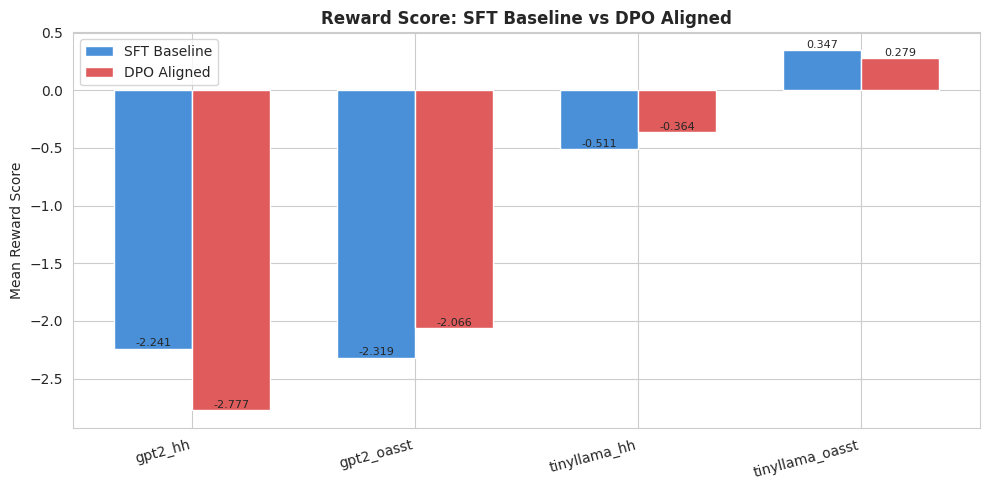

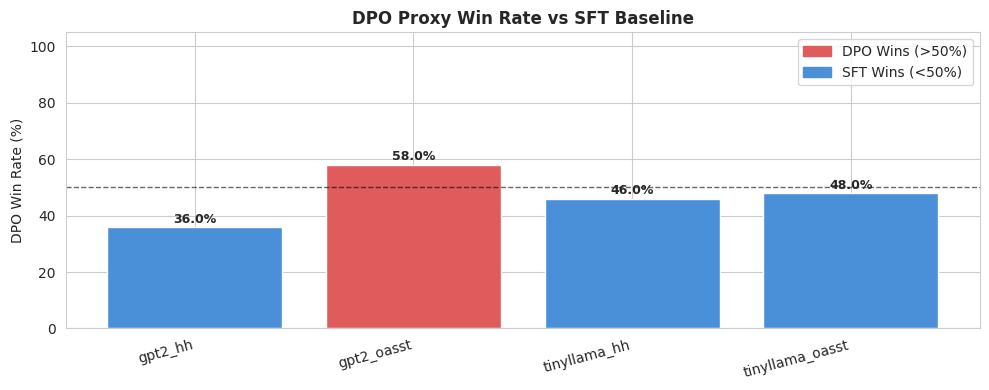

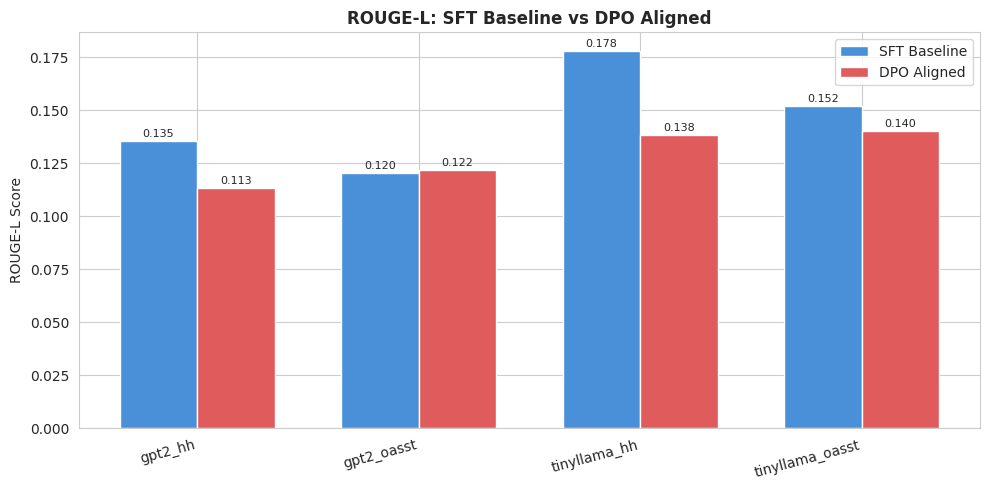

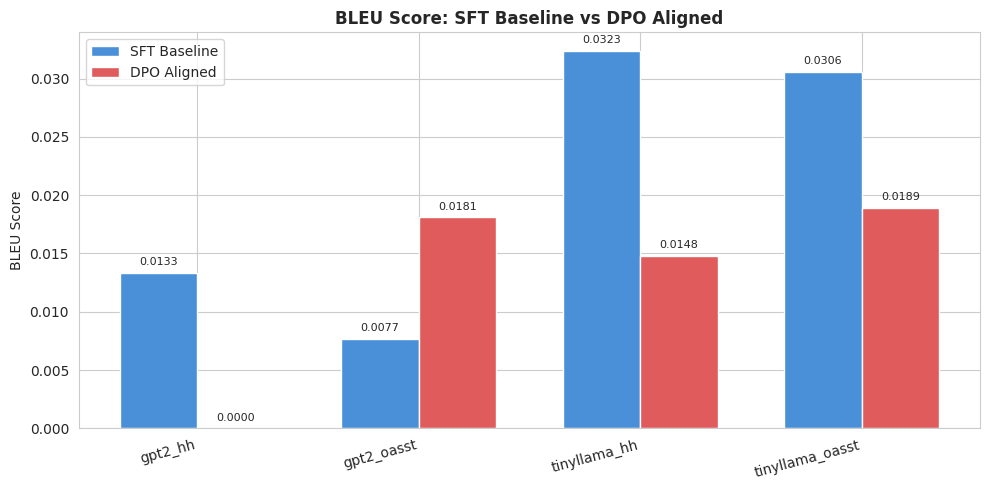

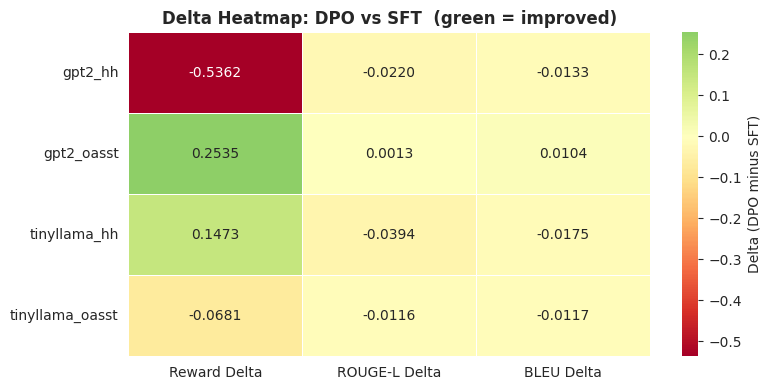


Summary CSV    : ./models/eval_summary.csv
Per-combo CSVs : ./models/{combo}_eval_results.csv
Figures        : vis1 through vis5 saved to ./models/

=== ALL 4 EVALUATIONS COMPLETE ===


In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "evaluate", "rouge_score", "-q"], check=True)

import os
import gc
import torch
import numpy as np
import pandas as pd
import evaluate
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig, pipeline,
)
from peft import PeftModel

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"=== STAGE 5: EVALUATION ===\nUsing device: {device}")

EVAL_SAMPLES   = 50
MAX_LENGTH     = 512
MAX_NEW_TOKENS = 50

BNB_CONFIG = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16,
)

# Each entry maps a combo name to: base model, SFT checkpoint, DPO checkpoint, RM checkpoint, quantized flag.
# quantized=True triggers 4-bit loading and manual safetensors key remapping for TinyLlama.
EVAL_MATRIX = {
    "gpt2_hh":        ("gpt2", "./models/baseline_sft/gpt2_hh_rlhf", "./models/dpo/gpt2_hh_rlhf", "./models/reward_models/gpt2_hh_rlhf", False),
    "gpt2_oasst":     ("gpt2", "./models/baseline_sft/gpt2_oasst", "./models/dpo/gpt2_oasst", "./models/reward_models/gpt2_oasst", False),
    "tinyllama_hh":   ("TinyLlama/TinyLlama-1.1B-Chat-v1.0", "./models/baseline_sft/tinyllama_hh_rlhf", "./models/dpo/tinyllama_hh_rlhf", "./models/reward_models/tinyllama_hh_rlhf", True),
    "tinyllama_oasst":("TinyLlama/TinyLlama-1.1B-Chat-v1.0", "./models/baseline_sft/tinyllama_oasst", "./models/dpo/tinyllama_oasst", "./models/reward_models/tinyllama_oasst", True),
}

print("\n[1/4] LOADING EVALUATION DATA")
def extract_anthropic_prompt(text):
    parts = text.split("\n\nAssistant:")
    prompt   = parts[0] + "\n\nAssistant:"
    response = parts[1].strip() if len(parts) > 1 else ""
    return prompt.strip(), response

hh_eval = load_dataset("Anthropic/hh-rlhf", split=f"test[:{EVAL_SAMPLES}]")
eval_records = []
for ex in hh_eval:
    prompt, chosen = extract_anthropic_prompt(ex["chosen"])
    eval_records.append({"prompt": prompt, "chosen": chosen})
prompts      = [r["prompt"] for r in eval_records]
human_chosen = [r["chosen"] for r in eval_records]
print(f"  -> {len(eval_records)} evaluation samples loaded.")

rouge_metric = evaluate.load("rouge")
bleu_metric  = evaluate.load("bleu")

def load_causal_model(base_id, ckpt, quantized):
    tok = AutoTokenizer.from_pretrained(base_id)
    tok.pad_token = tok.eos_token
    tok.padding_side = "left"
    if quantized:
        base = AutoModelForCausalLM.from_pretrained(base_id, quantization_config=BNB_CONFIG, device_map="auto", torch_dtype=torch.float16)
    else:
        base = AutoModelForCausalLM.from_pretrained(base_id, torch_dtype=torch.float16).to(device)
    model = PeftModel.from_pretrained(base, ckpt) if (ckpt and Path(ckpt).exists()) else base
    model.eval()
    return model, tok

def generate(model, tok, prompts_list):
    pipe = pipeline("text-generation", model=model, tokenizer=tok, max_new_tokens=MAX_NEW_TOKENS, pad_token_id=tok.eos_token_id, do_sample=False, batch_size=8)
    return [pipe(p, return_full_text=False)[0]["generated_text"].strip() for p in prompts_list]

# GPT-2 RM loads normally via PeftModel.from_pretrained.
# TinyLlama RM requires manual key remapping the DtypeSafeScoreHead wrapper changed the saved key name
def load_reward_model(base_id, ckpt, quantized):
    tok = AutoTokenizer.from_pretrained(base_id)
    tok.pad_token = tok.eos_token
    if not (ckpt and Path(ckpt).exists()):
        model = AutoModelForSequenceClassification.from_pretrained(base_id, num_labels=1, quantization_config=BNB_CONFIG, device_map="auto", torch_dtype=torch.float16) if quantized else AutoModelForSequenceClassification.from_pretrained(base_id, num_labels=1, torch_dtype=torch.float16).to(device)
        model.config.pad_token_id = tok.pad_token_id
        model.eval()
        return model, tok
    if not quantized:
        base = AutoModelForSequenceClassification.from_pretrained(base_id, num_labels=1, torch_dtype=torch.float16).to(device)
        model = PeftModel.from_pretrained(base, ckpt)
        model.config.pad_token_id = tok.pad_token_id
        model.eval()
        return model, tok
    adapter_file = Path(ckpt) / "adapter_model.safetensors"
    bin_file     = Path(ckpt) / "adapter_model.bin"
    if adapter_file.exists():
        import safetensors.torch as st
        raw_weights = st.load_file(str(adapter_file))
    elif bin_file.exists():
        raw_weights = torch.load(str(bin_file), map_location="cpu")
    else:
        raw_weights = None
    base = AutoModelForSequenceClassification.from_pretrained(base_id, num_labels=1, quantization_config=BNB_CONFIG, device_map="auto", torch_dtype=torch.float16)
    if raw_weights is None:
        base.config.pad_token_id = tok.pad_token_id
        base.eval()
        return base, tok
    remapped = {k.replace("base_model.model.score.modules_to_save.default.score.weight", "base_model.model.score.weight"): v for k, v in raw_weights.items()}
    from peft import PeftConfig
    peft_cfg = PeftConfig.from_pretrained(ckpt)
    peft_cfg.modules_to_save = None
    model = PeftModel(base, peft_cfg)
    model.load_state_dict(remapped, strict=False)
    model.config.pad_token_id = tok.pad_token_id
    model.eval()
    return model, tok

def score_responses(rm_model, rm_tok, prompts_list, responses):
    scores = []
    for p, r in zip(prompts_list, responses):
        enc = rm_tok(p + " " + r, return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(rm_model.device if hasattr(rm_model, "device") else device)
        with torch.no_grad():
            scores.append(rm_model(**enc).logits[0][0].item())
    return scores

# For each combo: generate 50 SFT responses, 50 DPO responses, score both with the RM,
# then compute ROUGE-L, BLEU, reward delta and win rate against SFT baseline.
print("\n[2/4] RUNNING EVALUATIONS")
all_summary = []

for combo, (base_id, sft_ckpt, dpo_ckpt, rm_ckpt, quantized) in EVAL_MATRIX.items():
    print(f"\n{'='*60}\nEVALUATING: {combo.upper()}\n{'='*60}")
    results = {"Prompt": prompts, "Human_Chosen": human_chosen, "SFT_Response": [], "DPO_Response": [], "SFT_Reward": [], "DPO_Reward": []}

    print("  Generating SFT responses...")
    sft_model, tok = load_causal_model(base_id, sft_ckpt, quantized)
    results["SFT_Response"] = generate(sft_model, tok, prompts)
    del sft_model; gc.collect()
    if device == "cuda": torch.cuda.empty_cache()

    print("  Generating DPO responses...")
    dpo_model, tok = load_causal_model(base_id, dpo_ckpt, quantized)
    results["DPO_Response"] = generate(dpo_model, tok, prompts)
    del dpo_model, tok; gc.collect()
    if device == "cuda": torch.cuda.empty_cache()

    print("  Scoring with reward model...")
    rm_model, rm_tok = load_reward_model(base_id, rm_ckpt, quantized)
    results["SFT_Reward"] = score_responses(rm_model, rm_tok, prompts, results["SFT_Response"])
    results["DPO_Reward"] = score_responses(rm_model, rm_tok, prompts, results["DPO_Response"])
    del rm_model, rm_tok; gc.collect()
    if device == "cuda": torch.cuda.empty_cache()

    sft_rouge = rouge_metric.compute(predictions=results["SFT_Response"], references=results["Human_Chosen"])["rougeL"]
    dpo_rouge = rouge_metric.compute(predictions=results["DPO_Response"], references=results["Human_Chosen"])["rougeL"]
    sft_bleu  = bleu_metric.compute(predictions=results["SFT_Response"], references=[[r] for r in results["Human_Chosen"]])["bleu"]
    dpo_bleu  = bleu_metric.compute(predictions=results["DPO_Response"], references=[[r] for r in results["Human_Chosen"]])["bleu"]

    avg_sft_reward = float(np.mean(results["SFT_Reward"]))
    avg_dpo_reward = float(np.mean(results["DPO_Reward"]))
    wins           = sum(1 for d, s in zip(results["DPO_Reward"], results["SFT_Reward"]) if d > s)
    win_rate       = (wins / EVAL_SAMPLES) * 100
    reward_delta   = avg_dpo_reward - avg_sft_reward
    rouge_delta    = dpo_rouge - sft_rouge
    bleu_delta     = dpo_bleu - sft_bleu

    print(f"\n  {'─'*40}\n  1. REWARD SCORE\n  {'─'*40}")
    print(f"  SFT Baseline : {avg_sft_reward:.4f}\n  DPO Aligned  : {avg_dpo_reward:.4f}")
    print(f"  Delta        : {reward_delta:+.4f}  ({'Improved' if reward_delta > 0 else 'Decreased (Alignment Failed)'})")
    print(f"\n  {'─'*40}\n  2. PROXY WIN RATE\n  {'─'*40}")
    print(f"  DPO Win Rate : {win_rate:.2f}%  ({'DPO Wins' if win_rate > 50 else 'SFT Wins' if win_rate < 50 else 'Tie'})")
    print(f"\n  {'─'*40}\n  3. ROUGE-L\n  {'─'*40}")
    print(f"  SFT Baseline : {sft_rouge:.4f}\n  DPO Aligned  : {dpo_rouge:.4f}")
    print(f"  Delta        : {rouge_delta:+.4f}  ({'Increased' if rouge_delta > 0 else 'Decreased (Alignment Tax)'})")
    print(f"\n  {'─'*40}\n  4. BLEU\n  {'─'*40}")
    print(f"  SFT Baseline : {sft_bleu:.4f}\n  DPO Aligned  : {dpo_bleu:.4f}")
    print(f"  Delta        : {bleu_delta:+.4f}  ({'Increased' if bleu_delta > 0 else 'Decreased (Alignment Tax)'})")
    print(f"  {'='*60}\n")

    pd.DataFrame(results).to_csv(f"./models/{combo}_eval_results.csv", index=False)
    all_summary.append({"combo": combo, "avg_sft_reward": avg_sft_reward, "avg_dpo_reward": avg_dpo_reward, "reward_delta": reward_delta, "win_rate": win_rate, "sft_rouge": sft_rouge, "dpo_rouge": dpo_rouge, "rouge_delta": rouge_delta, "sft_bleu": sft_bleu, "dpo_bleu": dpo_bleu, "bleu_delta": bleu_delta})

print("\n[3/4] SUMMARY TABLE")
print("="*80)
df = pd.DataFrame(all_summary).set_index("combo")
print(df[["avg_sft_reward","avg_dpo_reward","reward_delta","win_rate","sft_rouge","dpo_rouge","rouge_delta","sft_bleu","dpo_bleu","bleu_delta"]].to_string())
df.to_csv("./models/eval_summary.csv")

print("\n[4/4] GENERATING VISUALISATIONS")
sns.set_style("whitegrid")
combos = df.index.tolist()
x = np.arange(len(combos))
bar_w = 0.35
SFT_COLOR = "#4a90d9"
DPO_COLOR = "#e05c5c"

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - bar_w/2, df["avg_sft_reward"], bar_w, label="SFT Baseline", color=SFT_COLOR)
ax.bar(x + bar_w/2, df["avg_dpo_reward"], bar_w, label="DPO Aligned", color=DPO_COLOR)
for i, (s, d) in enumerate(zip(df["avg_sft_reward"], df["avg_dpo_reward"])):
    ax.text(i - bar_w/2, s + 0.002, f"{s:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + bar_w/2, d + 0.002, f"{d:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(combos, rotation=15, ha="right")
ax.set_title("Reward Score: SFT Baseline vs DPO Aligned", fontweight="bold")
ax.set_ylabel("Mean Reward Score"); ax.legend(); plt.tight_layout()
plt.savefig("./models/vis1_reward_before_after.png", dpi=150, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
win_colors = [DPO_COLOR if w > 50 else SFT_COLOR for w in df["win_rate"]]
bars = ax.bar(combos, df["win_rate"], color=win_colors, edgecolor="white")
ax.axhline(50, color="black", linestyle="--", linewidth=1, alpha=0.6)
for bar, v in zip(bars, df["win_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("DPO Proxy Win Rate vs SFT Baseline", fontweight="bold")
ax.set_ylabel("DPO Win Rate (%)"); ax.set_ylim(0, 105)
ax.set_xticklabels(combos, rotation=15, ha="right")
ax.legend(handles=[mpatches.Patch(color=DPO_COLOR, label="DPO Wins (>50%)"), mpatches.Patch(color=SFT_COLOR, label="SFT Wins (<50%)")])
plt.tight_layout(); plt.savefig("./models/vis2_win_rate.png", dpi=150, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - bar_w/2, df["sft_rouge"], bar_w, label="SFT Baseline", color=SFT_COLOR)
ax.bar(x + bar_w/2, df["dpo_rouge"], bar_w, label="DPO Aligned", color=DPO_COLOR)
for i, (s, d) in enumerate(zip(df["sft_rouge"], df["dpo_rouge"])):
    ax.text(i - bar_w/2, s + 0.001, f"{s:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + bar_w/2, d + 0.001, f"{d:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(combos, rotation=15, ha="right")
ax.set_title("ROUGE-L: SFT Baseline vs DPO Aligned", fontweight="bold")
ax.set_ylabel("ROUGE-L Score"); ax.legend(); plt.tight_layout()
plt.savefig("./models/vis3_rouge_before_after.png", dpi=150, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - bar_w/2, df["sft_bleu"], bar_w, label="SFT Baseline", color=SFT_COLOR)
ax.bar(x + bar_w/2, df["dpo_bleu"], bar_w, label="DPO Aligned", color=DPO_COLOR)
for i, (s, d) in enumerate(zip(df["sft_bleu"], df["dpo_bleu"])):
    ax.text(i - bar_w/2, s + 0.0005, f"{s:.4f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + bar_w/2, d + 0.0005, f"{d:.4f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(combos, rotation=15, ha="right")
ax.set_title("BLEU Score: SFT Baseline vs DPO Aligned", fontweight="bold")
ax.set_ylabel("BLEU Score"); ax.legend(); plt.tight_layout()
plt.savefig("./models/vis4_bleu_before_after.png", dpi=150, bbox_inches="tight"); plt.show()

delta_df = df[["reward_delta", "rouge_delta", "bleu_delta"]].copy()
delta_df.columns = ["Reward Delta", "ROUGE-L Delta", "BLEU Delta"]
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(delta_df, annot=True, fmt=".4f", center=0, cmap="RdYlGn", linewidths=0.5, ax=ax, cbar_kws={"label": "Delta (DPO minus SFT)"})
ax.set_title("Delta Heatmap: DPO vs SFT  (green = improved)", fontweight="bold")
ax.set_ylabel(""); plt.xticks(rotation=0); plt.yticks(rotation=0); plt.tight_layout()
plt.savefig("./models/vis5_delta_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

print("\nSummary CSV    : ./models/eval_summary.csv")
print("Per-combo CSVs : ./models/{combo}_eval_results.csv")
print("Figures        : vis1 through vis5 saved to ./models/")
print("\n=== ALL 4 EVALUATIONS COMPLETE ===")